# Andamento Autovetture Elettriche e Ibride per Area Geografica
**Confronto Nord / Centro / Sud — 2015–2023**

Fonte dati: ISTAT — autovetture per 1.000 autovetture circolanti

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

## 1. Lettura dei dati

In [65]:
df_el = pd.read_csv('../data/csv/auto_elettr_su_1000.csv', index_col=False)
df_hy = pd.read_csv('../data/csv/auto_ibride_su_1000.csv', index_col=False)

# Converti subito dopo la lettura
df_el['Osservazione'] = pd.to_numeric(df_el['Osservazione'], errors='coerce')
df_hy['Osservazione'] = pd.to_numeric(df_hy['Osservazione'], errors='coerce')

# Verifica
print(df_el['Osservazione'].dtype)  # deve stampare float64

float64


## 2. Debug: verifica colonne e valori unici

In [66]:
aree = ['Nord', 'Centro', 'Sud']
df_el_aree = df_el[df_el['Territorio'].isin(aree)].copy()
print(len(df_el_aree))
print(df_el_aree['Territorio'].unique())

27
['Nord' 'Centro' 'Sud']


In [67]:
print(df_el_aree[['Territorio', 'TIME_PERIOD', 'Osservazione']].to_string())
print()
print('Tipo TIME_PERIOD:', df_el_aree['TIME_PERIOD'].dtype)
print('Tipo Osservazione:', df_el_aree['Osservazione'].dtype)

    Territorio  TIME_PERIOD  Osservazione
9         Nord         2015           0.2
10        Nord         2016           0.2
11        Nord         2017           0.3
12        Nord         2018           0.5
13        Nord         2019           0.9
14        Nord         2020           2.2
15        Nord         2021           4.6
16        Nord         2022           5.8
17        Nord         2023           8.0
468     Centro         2015           0.2
469     Centro         2016           0.3
470     Centro         2017           0.3
471     Centro         2018           0.5
472     Centro         2019           0.9
473     Centro         2020           1.7
474     Centro         2021           3.6
475     Centro         2022           4.8
476     Centro         2023           6.9
684        Sud         2015           0.1
685        Sud         2016           0.1
686        Sud         2017           0.1
687        Sud         2018           0.2
688        Sud         2019       

## 3. Filtra le macro aree geografiche (Nord, Centro, Sud)

In [68]:
aree = ['Nord', 'Centro', 'Sud']

# ATTENZIONE: filtrare su 'Territorio', NON su 'Frequenza'
df_el_aree = df_el[df_el['Territorio'].isin(aree)].copy()
df_hy_aree = df_hy[df_hy['Territorio'].isin(aree)].copy()

# Debug: verifica che il filtro abbia funzionato
print('Righe elettriche dopo filtro:', len(df_el_aree))
print('Righe ibride dopo filtro:', len(df_hy_aree))
df_el_aree.head()

Righe elettriche dopo filtro: 27
Righe ibride dopo filtro: 27


,FREQ,Frequenza,REF_AREA,Territorio,DATA_TYPE,Indicatore,TIME_PERIOD,Osservazione,OBS_STATUS,"'Stato dell""'osservazione'",...,NOTE_DATA_TYPE,Indicatore (NOTE_DATA_TYPE),NOTE_TIME_PERIOD,Tempo (NOTE_TIME_PERIOD),BASE_PER,Anno base,UNIT_MEAS,Unità di misura,UNIT_MULT,Unità di moltiplicazione
9,A,Annuale,ITCD,Nord,FULECAR1000,Autovetture elettriche - per 1.000 autovetture,2015,0.2,NaN,NaN,...,Nord,Nord-est e Capoluoghi di provincia non includ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,A,Annuale,ITCD,Nord,FULECAR1000,Autovetture elettriche - per 1.000 autovetture,2016,0.2,NaN,NaN,...,Nord,Nord-est e Capoluoghi di provincia non includ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,A,Annuale,ITCD,Nord,FULECAR1000,Autovetture elettriche - per 1.000 autovetture,2017,0.3,NaN,NaN,...,Nord,Nord-est e Capoluoghi di provincia non includ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,A,Annuale,ITCD,Nord,FULECAR1000,Autovetture elettriche - per 1.000 autovetture,2018,0.5,NaN,NaN,...,Nord,Nord-est e Capoluoghi di provincia non includ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,A,Annuale,ITCD,Nord,FULECAR1000,Autovetture elettriche - per 1.000 autovetture,2019,0.9,NaN,NaN,...,Nord,Nord-est e Capoluoghi di provincia non includ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Conversione colonna Osservazione a numerico

In [69]:
df_el_aree['Osservazione'] = pd.to_numeric(df_el_aree['Osservazione'], errors='coerce')
df_hy_aree['Osservazione'] = pd.to_numeric(df_hy_aree['Osservazione'], errors='coerce')

# Debug: controlla NaN dopo conversione
print('NaN elettriche:', df_el_aree['Osservazione'].isna().sum())
print('NaN ibride:', df_hy_aree['Osservazione'].isna().sum())

NaN elettriche: 0
NaN ibride: 0


## 5. Grafico a linee — confronto Nord / Centro / Sud

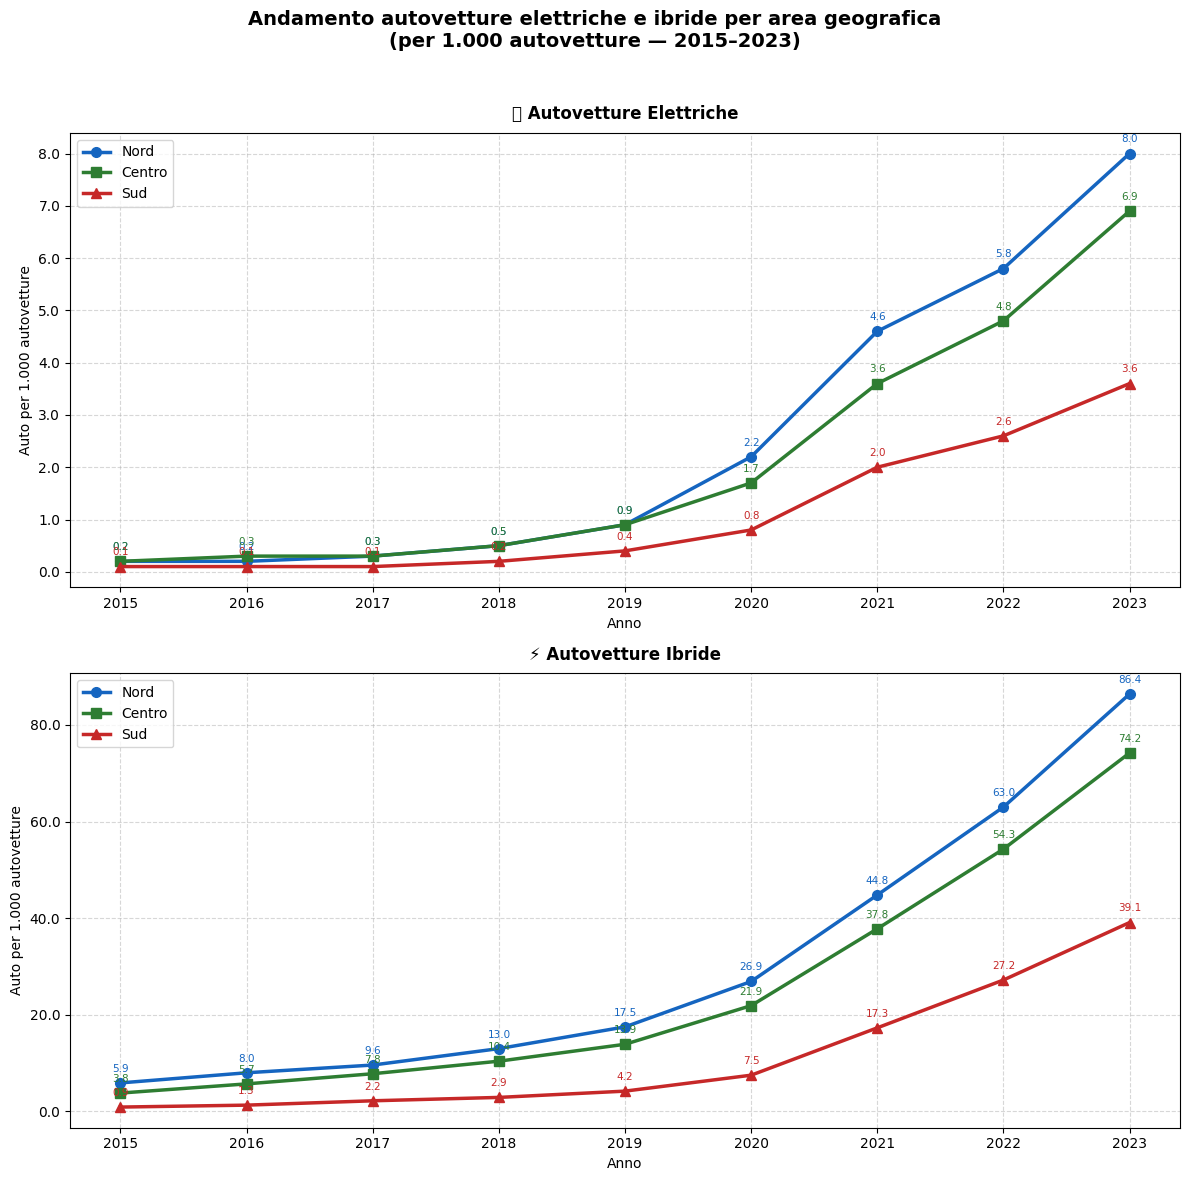

In [70]:
colori  = {'Nord': '#1565C0', 'Centro': '#2E7D32', 'Sud': '#C62828'}
markers = {'Nord': 'o',       'Centro': 's',        'Sud': '^'}

fig, axes = plt.subplots(2, 1, figsize=(12, 12))
fig.suptitle(
    'Andamento autovetture elettriche e ibride per area geografica\n'
    '(per 1.000 autovetture — 2015–2023)',
    fontsize=14, fontweight='bold', y=0.98
)

titoli   = ['🔋 Autovetture Elettriche', '⚡ Autovetture Ibride']
datasets = [df_el_aree, df_hy_aree]

for ax, df, titolo in zip(axes, datasets, titoli):
    for area in aree:
        dati = df[df['Territorio'] == area].sort_values('TIME_PERIOD')
        ax.plot(
            dati['TIME_PERIOD'], dati['Osservazione'],
            label=area,
            color=colori[area],
            marker=markers[area],
            linewidth=2.5,
            markersize=7
        )
        # Etichette valori sui punti
        for _, row in dati.iterrows():
            ax.annotate(
                f"{row['Osservazione']:.1f}",
                xy=(row['TIME_PERIOD'], row['Osservazione']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=7.5, color=colori[area]
            )

    ax.set_title(titolo, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Anno', fontsize=10)
    ax.set_ylabel('Auto per 1.000 autovetture', fontsize=10)
    ax.set_xticks(range(2015, 2024))
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()